# 0. NOTEBOOK PREPARATION

In [1]:
import eos
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
from IPython.display import display, Latex
#import re
import yaml
#from tabulate import tabulate
from wquantiles import quantile
from collections import OrderedDict
print(eos.__version__)

#BASE_DIRECTORY='./data_base'
BASE_DIRECTORY='./test_base'
#ANALYSIS_FILE='./an_file.yaml'
ANALYSIS_FILE='./an_file_BK.yaml'

POSTERIOR_NAME = 'BSZ-BqToK-wSR-wNFF-wCov'

def weighted_mean_std(samples, weights):
    mean = np.average(samples, weights=weights)
    var = np.average((samples - mean) ** 2, weights=weights)
    return mean, np.sqrt(var)

def find_index_for_q2(prediction, obs_name, q2_value):
    candidates = []
    for idx, item in enumerate(prediction.varied_parameters):
        if item.get('name') != obs_name:
            continue
        kin = item.get('kinematics', {})

        # Point-like kinematics
        if 'q2' in kin:
            candidates.append((idx, float(kin['q2'])))
            continue
        if 's' in kin:
            candidates.append((idx, float(kin['s'])))
            continue

        # Binned kinematics
        if 'q2_min' in kin and 'q2_max' in kin:
            q2c = 0.5 * (float(kin['q2_min']) + float(kin['q2_max']))
            candidates.append((idx, q2c))
            continue
        if 's_min' in kin and 's_max' in kin:
            q2c = 0.5 * (float(kin['s_min']) + float(kin['s_max']))
            candidates.append((idx, q2c))
            continue

    if not candidates:
        return None, None
    idx, q2_best = min(candidates, key=lambda t: abs(t[1] - q2_value))
    return idx, q2_best

def range_from_pred(prediction, obs_name, q2_vals, nsigma=3.0, pad_frac=0.1):
    vals = []
    for q2 in q2_vals:
        idx, _ = find_index_for_q2(prediction, obs_name, q2)
        if idx is None:
            continue
        mean, std = weighted_mean_std(prediction.samples[:, idx], prediction.weights)
        vals.extend([mean - nsigma * std, mean + nsigma * std])
    if not vals:
        return [0.0, 1.0]
    vmin, vmax = min(vals), max(vals)
    pad = (vmax - vmin) * pad_frac if vmax != vmin else max(abs(vmin) * pad_frac, 1e-4)
    return [vmin - pad, vmax + pad]

def print_params_from_posterior(base, posterior):
    posterior_dir = os.path.join(base, 'data', posterior, 'samples')

    data = eos.data.ImportanceSamples(posterior_dir)
    samples = data.samples
    weights = data.weights
    varied = [p["name"] for p in data.varied_parameters]
    for name in varied:
        idx = varied.index(name)
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{name}: {mean:e} ± {std:.2e}")

def print_pred_from_posterior(base, posterior, pred_name, obs_name, q2_vals):
    pred_dir = os.path.join(base, 'data', posterior, f'pred-{pred_name}')
    data = eos.data.Prediction(pred_dir)
    samples = data.samples
    weights = data.weights

    idx_q2best = []
    for q2 in q2_vals:
        idx, q2_best = find_index_for_q2(data, obs_name, q2)
        if idx is not None:
            idx_q2best.append((idx, q2_best))
    if not idx_q2best:
        print(f"No entries found for {obs_name} in {pred_name}")
        return
    for idx, q2_best in idx_q2best:
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{obs_name} at q^2={q2_best:.1f}: {mean:e} ± {std:.2e}")

def print_ranges_from_posterior(base, posterior, nsigma=3.0): 
    posterior_dir = os.path.join(base, 'data', posterior, 'samples')

    data = eos.data.ImportanceSamples(posterior_dir)
    samples = data.samples
    weights = data.weights
    varied = [p["name"] for p in data.varied_parameters]
    for name in varied:
        idx = varied.index(name)
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"- {{ parameter: '{name}', min: {mean - nsigma * std:.3e}, max: {mean + nsigma * std:.3e}, type: 'uniform'}}")

def pred_from_posterior(base, posterior, pred_name, obs_name, q2):
    pred_dir = os.path.join(base, 'data', posterior, f'pred-{pred_name}')
    data = eos.data.Prediction(pred_dir)
    samples = data.samples
    weights = data.weights

    idx, q2_best = find_index_for_q2(data, obs_name, q2)
    if idx is None:
        print(f"No entries found for {obs_name} in {pred_name}")
        return
    
    mean, std = weighted_mean_std(samples[:, idx], weights)
    return mean, std

def weighted_mean_cov(X, w, unbiased=False):
    # X has shape (N_samples, N_observables)
    w = np.asarray(w, dtype=float)
    w = w / np.sum(w)

    #mu = np.sum(X * w[:, None], axis=0) # weighted sum with normalized weights, equivalent to average
    mu = w @ X
    Xm = X - mu
    cov = (w[:, None] * Xm).T @ Xm  # MLE weighted covariance

    if unbiased:
        neff = 1.0 / np.sum(w**2)
        if neff > 1.0:
            cov *= neff / (neff - 1.0)

    return mu, cov

1.0.19


# temporary: chiOPE

In [ ]:
import re

In [ ]:
expression = R"""(
        -1/24*(alpha_s*
        (Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]*(5*m1^6 + 16*m1^5*m2 - 5*m1^4*m2^2 - 
        32*m1^3*m2^3 - 5*m1^2*m2^4 + 16*m1*m2^5 + 5*m2^6 + 4*m1^4*s - 
        42*m1^3*m2*s - 68*m1^2*m2^2*s - 42*m1*m2^3*s + 4*m2^4*s - 15*m1^2*s^2 + 
        42*m1*m2*s^2 - 15*m2^2*s^2 + 6*s^3 - m1^6*Log[4] - m2^6*Log[4] - 
        m1^5*m2*Log[16] - m1*m2^5*Log[16] + 2*m1*m2*s^2*Log[4096] + 
        2*s^3*Log[4096] + m1^6*Log[16384] + m2^6*Log[16384] - 
        2*m1^2*s^2*Log[262144] - 2*m2^2*s^2*Log[262144] - 
        2*m1^3*m2^3*Log[16777216] - 2*m1^3*m2*s*Log[16777216] - 
        2*m1*m2^3*s*Log[16777216] + m1^5*m2*Log[268435456] + 
        m1*m2^5*Log[268435456] - 2*m1^2*m2^2*s*Log[281474976710656] + 
        m1^4*m2^2*Log[1125899906842624] + m1^2*m2^4*Log[1125899906842624] - 
        m1^4*m2^2*Log[4611686018427387904] - 
        m1^2*m2^4*Log[4611686018427387904] + 
        6*(3*m1^6 + 4*m1^5*m2 + 2*m1*m2*(2*m2^2 - 2*s)*(m2^2 - s) - 
        m1^4*(5*m2^2 + 2*s) + (m2^2 - s)^2*(m2^2 + 4*s) - 
        2*m1^3*m2*(4*m2^2 + 4*s) + m1^2*(m2^4 - 16*m2^2*s - 5*s^2))*Log[m1] + 
        6*(m1^6 + 4*m1^5*m2 + m1^4*(m2^2 + 2*s) - 2*m1^3*m2*(4*m2^2 + 4*s) + 
        (m2^2 - s)*(3*m2^4 + m2^2*s - 4*s^2) + 
        2*m1*m2*(2*m2^4 - 4*m2^2*s + 2*s^2) - m1^2*(5*m2^4 + 16*m2^2*s + 
        7*s^2))*Log[m2] + 12*m1^6*
        Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^(-1)] + 
        24*m1^5*m2*Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])^(-1)] - 12*m1^4*m2^2*
        Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^(-1)] - 
        48*m1^3*m2^3*Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])^(-1)] - 12*m1^2*m2^4*
        Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^(-1)] + 
        24*m1*m2^5*Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])^(-1)] + 12*m2^6*Log[(-m1^2 - m2^2 + s + 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^(-1)] - 
        48*m1^3*m2*s*Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])^(-1)] - 96*m1^2*m2^2*s*
        Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^(-1)] - 
        48*m1*m2^3*s*Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])^(-1)] - 36*m1^2*s^2*
        Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^(-1)] + 
        24*m1*m2*s^2*Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])^(-1)] - 36*m2^2*s^2*
        Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^(-1)] + 
        24*s^3*Log[(-m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^
        (-1)] + 4*m1^6*Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] + 8*m1^5*m2*
        Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] - 
        4*m1^4*m2^2*Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] - 16*m1^3*m2^3*
        Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] - 
        4*m1^2*m2^4*Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] + 8*m1*m2^5*
        Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] + 
        4*m2^6*Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] - 
        16*m1^3*m2*s*Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] - 32*m1^2*m2^2*s*
        Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] - 
        16*m1*m2^3*s*Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] - 12*m1^2*s^2*
        Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] + 
        8*m1*m2*s^2*Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] - 12*m2^2*s^2*
        Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] + 
        8*s^3*Log[-((m1^2 - m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] + 
        4*m1^6*Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] + 
        8*m1^5*m2*Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] - 4*m1^4*m2^2*
        Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] - 
        16*m1^3*m2^3*Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] - 4*m1^2*m2^4*
        Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] + 
        8*m1*m2^5*Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] + 4*m2^6*
        Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] - 
        16*m1^3*m2*s*Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] - 32*m1^2*m2^2*s*
        Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] - 
        16*m1*m2^3*s*Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] - 12*m1^2*s^2*
        Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] + 
        8*m1*m2*s^2*Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]]))] - 12*m2^2*s^2*
        Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] + 
        8*s^3*Log[-((-m1^2 + m2^2 + s + Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]]))] - 
        16*m1^6*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] - 
        32*m1^5*m2*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] + 
        16*m1^4*m2^2*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] + 
        64*m1^3*m2^3*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] + 
        16*m1^2*m2^4*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] - 
        32*m1*m2^5*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] - 
        16*m2^6*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] + 
        64*m1^3*m2*s*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] + 
        128*m1^2*m2^2*s*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] + 
        64*m1*m2^3*s*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] + 
        48*m1^2*s^2*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] - 
        32*m1*m2*s^2*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] + 
        48*m2^2*s^2*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] - 
        32*s^3*Log[(m1^4 + (m2^2 - s)^2 - 2*m1^2*(m2^2 + s) - 
        2*(m1^2 + m2^2 - s)*Sqrt[Kallen\[Lambda][m1^2, m2^2, s]] + 
        Kallen\[Lambda][m1^2, m2^2, s])/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]) + 
        (m1^2 + 2*m1*m2 + m2^2 - s)*
        (4*m1^6*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] - 12*m1^4*m2^2*
        Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 12*m1^2*m2^4*
        Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 4*m2^6*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        4*m1^4*s*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        24*m1^3*m2*s*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        24*m1*m2^3*s*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        4*m2^4*s*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        16*m1^2*s^2*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        16*m2^2*s^2*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        4*m1^6*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] + 12*m1^4*m2^2*
        Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 12*m1^2*m2^4*
        Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 4*m2^6*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        4*m1^4*s*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        24*m1^3*m2*s*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        24*m1*m2^3*s*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        4*m2^4*s*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        16*m1^2*s^2*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        16*m2^2*s^2*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        m1^6*Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 6*m1^5*m2*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        11*m1^4*m2^2*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        24*m1^3*m2^3*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        m1^2*m2^4*Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] + 6*m1*m2^5*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        3*m2^6*Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] + 2*m1^4*s*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        12*m1^2*m2^2*s*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        24*m1*m2^3*s*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        6*m2^4*s*Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] - 5*m1^2*s^2*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        18*m1*m2*s^2*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        21*m2^2*s^2*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        12*s^3*Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] - 8*m1^6*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        8*m1^4*m2^2*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 8*m1^2*m2^4*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        8*m2^6*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 48*m1^3*m2*s*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        32*m1^2*m2^2*s*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 48*m1*m2^3*s*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        24*m1^2*s^2*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 48*m1*m2*s^2*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        24*m2^2*s^2*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 16*s^3*Log[1 - (4*m1^2*m2^2)/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 4*m1^6*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 4*m1^4*m2^2*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 4*m1^2*m2^4*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 4*m2^6*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 24*m1^3*m2*s*
        Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])]*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        16*m1^2*m2^2*s*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 24*m1*m2^3*s*
        Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])]*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        12*m1^2*s^2*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 24*m1*m2*s^2*
        Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])]*Log[(-2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        12*m2^2*s^2*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 8*s^3*Log[1 - (2*m1^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 3*m1^6*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        6*m1^5*m2*Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] - m1^4*m2^2*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        24*m1^3*m2^3*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        11*m1^2*m2^4*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        6*m1*m2^5*Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] - m2^6*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        6*m1^4*s*Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] - 24*m1^3*m2*s*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 12*m1^2*m2^2*s*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        2*m2^4*s*Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] - 21*m1^2*s^2*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 18*m1*m2*s^2*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        5*m2^2*s^2*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        12*s^3*Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] - 8*m1^6*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        8*m1^4*m2^2*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 8*m1^2*m2^4*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        8*m2^6*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 48*m1^3*m2*s*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        32*m1^2*m2^2*s*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 48*m1*m2^3*s*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        24*m1^2*s^2*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 48*m1*m2*s^2*
        Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])^2]*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        24*m2^2*s^2*Log[1 - (4*m1^2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 16*s^3*Log[1 - (4*m1^2*m2^2)/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 4*m1^6*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 4*m1^4*m2^2*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 4*m1^2*m2^4*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 4*m2^6*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 24*m1^3*m2*s*
        Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])]*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        16*m1^2*m2^2*s*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 24*m1*m2^3*s*
        Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])]*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        12*m1^2*s^2*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 24*m1*m2*s^2*
        Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])]*Log[(-2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        12*m2^2*s^2*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] + 8*s^3*Log[1 - (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])]*
        Log[(-2*m2^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, 
        s]])] - 16*(m1^6 - m1^4*m2^2 - 6*m1^3*m2*s + 
        6*m1*m2*s*(-m2^2 + s) + (m2^2 - s)^2*(m2^2 + 2*s) - 
        m1^2*(m2^4 - 4*m2^2*s + 3*s^2))*PolyLog[2, (4*m1^2*m2^2)/
        (m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])^2] + 
        8*(m1^6 - m1^4*m2^2 - 6*m1^3*m2*s + 6*m1*m2*s*(-m2^2 + s) + 
        (m2^2 - s)^2*(m2^2 + 2*s) - m1^2*(m2^4 - 4*m2^2*s + 3*s^2))*
        PolyLog[2, (2*m1^2)/(m1^2 + m2^2 - s - Sqrt[Kallen\[Lambda][m1^2, 
        m2^2, s]])] + 8*m1^6*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        8*m1^4*m2^2*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        8*m1^2*m2^4*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        8*m2^6*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        48*m1^3*m2*s*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        32*m1^2*m2^2*s*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        48*m1*m2^3*s*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        24*m1^2*s^2*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        48*m1*m2*s^2*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] - 
        24*m2^2*s^2*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])] + 
        16*s^3*PolyLog[2, (2*m2^2)/(m1^2 + m2^2 - s - 
        Sqrt[Kallen\[Lambda][m1^2, m2^2, s]])])))/
        (Pi^2*(m1^2 + 2*m1*m2 + m2^2 - s)*s^2)
    ) """;

In [ ]:
expression=expression.replace("^", "**").replace("[", "(").replace("]", ")")
expression = re.sub(
    r"Sqrt\(Kallen\\\(Lambda\)\(m1\*\*2,\s*m2\*\*2,\s*s\)\)",
    "np.sqrt(lambda_k(s))",
    expression
)
expression = expression.replace("PolyLog", "mp.polylog").replace("Log", "np.log").replace("Pi", "np.pi").replace("Sqrt(Kallen\(Lambda)(m1**2, m2**2, s))", "np.sqrt(lambda_k(s))")
print(expression)

## TEMPORARY [scale variation]

In [ ]:
pred_names = ['BToK-Re(H0)', 'BToK-Im(H0)']
obs_names = ['B->K::Re{H_plus}(q2)', 'B->K::Im{H_plus}(q2)']
q2_vals = [-6.0,0.0,6.0]

for i in range(len(pred_names)):
    print_pred_from_posterior(BASE_DIRECTORY, POSTERIOR_NAME, pred_names[i], obs_names[i], q2_vals)

In [ ]:
p = eos.Parameters.Defaults()
m = eos.Model.make('SM', p, eos.Options())
#p["mass::B_s^*"].evaluate()

mJpsi = p["mass::J/psi"].evaluate()
mPsi2S = p["mass::psi(2S)"].evaluate()
mD = p["mass::D^0"].evaluate()

print(mJpsi**2)
print(mPsi2S**2)
print(4 * mD**2)

In [ ]:
p = eos.Parameters.Defaults()
m = eos.Model.make('SM', p, eos.Options())

def wc(mu):
    return m.wilson_coefficients_b_to_s(mu, 1, False)

wc = wc(4.18)

print (wc.c1(), wc.c2())

In [ ]:
def FF(WC_number, q2, diag_class, mu, which = 'all'):
    p = eos.Parameters.Defaults()
    m = eos.Model.make('SM', p, eos.Options())

    def wc(mu):
        return m.wilson_coefficients_b_to_s(mu, 1, False)

    wc = wc(mu)

    #p.set("mass::b(MSbar)", m.m_b_msbar(mu))

    p.set("mass::c", 1.44423)
    #p.set("mass::c", 1.2122)
    p.set("sb::mu", mu)

    q2_Re = q2
    q2_Im = 0.0 

    kinematics = {"Re{q2}": q2_Re, "Im{q2}": q2_Im}

    # build observable names for the C1 and C2 contributions
    re_name1 = f"b->s::Re{{F1{WC_number}}}(Re{{q2}},Im{{q2}})"
    im_name1 = f"b->s::Im{{F1{WC_number}}}(Re{{q2}},Im{{q2}})"
    re_name2 = f"b->s::Re{{F2{WC_number}}}(Re{{q2}},Im{{q2}})"
    im_name2 = f"b->s::Im{{F2{WC_number}}}(Re{{q2}},Im{{q2}})"

    real_part1 = eos.Observable.make(re_name1, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()
    imag_part1 = eos.Observable.make(im_name1, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()
    real_part2 = eos.Observable.make(re_name2, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()
    imag_part2 = eos.Observable.make(im_name2, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()

    if(which == 'all'):
        print(f"F1{WC_number} : Re = {real_part1}, Im = {imag_part1}")
        print(f"F2{WC_number} : Re = {real_part2}, Im = {imag_part2}")
    if(which == 'F1'):
        print(f"F1{WC_number} : Re = {real_part1}, Im = {imag_part1}")
    if(which == 'F2'):
        print(f"F2{WC_number} : Re = {real_part2}, Im = {imag_part2}")

In [ ]:
for q2 in [-6.0, 1.0, 6.0]:
    for mu in [2.09, 4.18, 8.36]:
        print(f"Results for q^2 = {q2} GeV^2 and mu = {mu} GeV:")
        FF('7', q2, 'Qc', mu, which='F1')
        #FF('9', q2, 'Qc', mu)

for q2 in [-6.0, 1.0, 6.0]:
    for mu in [2.09, 4.18, 8.36]:
        print(f"Results for q^2 = {q2} GeV^2 and mu = {mu} GeV:")
        #FF('7', q2, 'Qc', mu)
        FF('9', q2, 'Qc', mu, which='F1')

for q2 in [-6.0, 1.0, 6.0]:
    for mu in [2.09, 4.18, 8.36]:
        print(f"Results for q^2 = {q2} GeV^2 and mu = {mu} GeV:")
        FF('7', q2, 'Qc', mu, which='F2')
        #FF('9', q2, 'Qc', mu)

for q2 in [-6.0, 1.0, 6.0]:
    for mu in [2.09, 4.18, 8.36]:
        print(f"Results for q^2 = {q2} GeV^2 and mu = {mu} GeV:")
        #FF('7', q2, 'Qc', mu)
        FF('9', q2, 'Qc', mu, which='F2')

In [ ]:
def DeltaC_Qc(WC_number, s, mu):

    p = eos.Parameters.Defaults()
    m = eos.Model.make('SM', p, eos.Options())

    def wc(mu):
        return m.wilson_coefficients_b_to_s(mu, 1, False)
    wc = wc(mu)
    
    #p.set('b->s::c1', -0.287213)
    #p.set('b->s::c2', 1.009)
    #p.set("mass::b(MSbar)", 4.18)
    p.set("mass::c", 1.44423)
    p.set("sb::mu", mu)
    p.set('b->s::c1', np.real(wc.c1()))
    p.set('b->s::c2', np.real(wc.c2()))

    q2_Re = s
    kinematics = {"q2": q2_Re}

    re_name = "b->s::Re{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc")
    im_name = "b->s::Im{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc")

    # make observables and evaluate
    real_part = eos.Observable.make(re_name, p, eos.Kinematics(kinematics), eos.Options({"model":"SM"})).evaluate()
    imag_part = eos.Observable.make(im_name, p, eos.Kinematics(kinematics), eos.Options({"model":"SM"})).evaluate()

    # Must add the fLO

    DC_Re = real_part
    DC_Im = imag_part

    return DC_Re + 1j * DC_Im

In [ ]:
q2_vals = [-6.0, 6.0]

for q2 in q2_vals:
    for mu in [2.09, 4.18, 8.36]:
        print(f"Results for q^2 = {q2} GeV^2 and mu = {mu} GeV:")
        print(f"DeltaC7({q2}, mu={mu}) = {DeltaC_Qc('7', q2, mu)}\tDeltaC9({q2}, mu={mu}) = {DeltaC_Qc('9', q2, mu)}")


# 3. $\Delta C_{9,7}$ evaluation

## 3.1 Check with Nico's nb

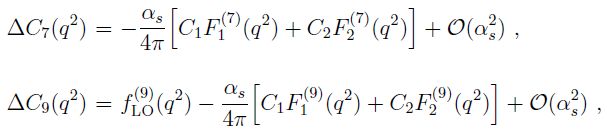

Nico's values from Méril's NB:

In [ ]:
# Nico's points are [Re(dC7(-7)), Im(dC7(-7)), Re(dC9(-7)), Im(dC9(-7)), Re(dC7(-5)), Im(dC7(-5)), Re(dC9(-5)), Im(dC9(-5)), Re(dC7(-3)), Im(dC7(-3)), Re(dC9(-3)), Im(dC9(-3)), Re(dC7(-1)), Im(dC7(-1)), Re(dC9(-1)), Im(dC9(-1))]
np.array([
    -0.04772609914476168, -0.00183730036829226, 0.07853072280327339, 0.000908821307728336,
    -0.05001585076240161, -0.00217806915487611, 0.10502127454492018, 0.000967628009215721,
    -0.05247358603064688, -0.00262107339844842, 0.13497045338769842, 0.000989307736797652,
    -0.05510828431004989, -0.003209557376766988, 0.16960820080628938, 0.0009129068295559907
])

In [ ]:
# OBSOLETE: used just to compare with 'myDeltaC_Qc' for WC_number = '7'

# For now only valid for WC_number = '7' bc I have to add the LO for '9'
def DeltaC(WC_number, diag_class, s_Re, s_Im):

    if WC_number == '9':
        fLO = 0  # Placeholder for future implementation
    else:
        fLO = 0

    test_flag = 0
    
    p = eos.Parameters.Defaults()

    # C1 = p['b->s::c1'].evaluate()
    # C2 = p['b->s::c2'].evaluate()
    C1 = -0.287213
    C2 = 1.009
    p.set("mass::b(MSbar)", 4.18)
    p.set("mass::c", 1.44423)
    #p.set("mass::c", 1.2122)
    p.set("sb::mu", 4.18)
    alpha_s = 0.226964 # from Nico's Mathematica at mu_b = 4.18

    q2_Re = s_Re 
    q2_Im = s_Im 

    kinematics = {"Re{q2}": q2_Re, "Im{q2}": q2_Im}

    # build observable names for the C1 and C2 contributions
    re_name1 = "b->s::Re{{{}}}(Re{{q2}},Im{{q2}})".format(f"F1{WC_number}")
    im_name1 = "b->s::Im{{{}}}(Re{{q2}},Im{{q2}})".format(f"F1{WC_number}")
    re_name2 = "b->s::Re{{{}}}(Re{{q2}},Im{{q2}})".format(f"F2{WC_number}")
    im_name2 = "b->s::Im{{{}}}(Re{{q2}},Im{{q2}})".format(f"F2{WC_number}")

    if test_flag:
        print("Observable names:")
        print(re_name1)
        print(im_name1)
        print(re_name2)
        print(im_name2)

    # make observables and evaluate
    real_part1 = eos.Observable.make(re_name1, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()
    imag_part1 = eos.Observable.make(im_name1, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()
    real_part2 = eos.Observable.make(re_name2, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()
    imag_part2 = eos.Observable.make(im_name2, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()

    if test_flag:
        print("Real and Imaginary parts:")
        print("C1 contribution: Re = {}, Im = {}".format(real_part1, imag_part1))
        print("C2 contribution: Re = {}, Im = {}".format(real_part2, imag_part2))

    # Must add the fLO

    DC_Re = - alpha_s/(4.0*np.pi) * (C1*real_part1 + C2*real_part2)
    DC_Im = - alpha_s/(4.0*np.pi) * (C1*imag_part1 + C2*imag_part2)

    return DC_Re + 1j * DC_Im


def myDeltaC_Qc(WC_number, s_Re):

    test_flag = 0
    
    p = eos.Parameters.Defaults()
    p.set('b->s::c1', -0.287213)
    p.set('b->s::c2', 1.009)
    p.set("mass::b(MSbar)", 4.18)
    p.set("mass::c", 1.44423)
    p.set("sb::mu", 4.18)
    #alpha_s = 0.226964 # from Nico's Mathematica at mu_b = 4.18

    q2_Re = s_Re 
    kinematics = {"q2": q2_Re}

    re_name = "b->s::Re{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc")
    im_name = "b->s::Im{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc")

    if test_flag:
        print("Observable names:")
        print(re_name)
        print(im_name)

    # make observables and evaluate
    real_part = eos.Observable.make(re_name, p, eos.Kinematics(kinematics), eos.Options({"model":"WET"})).evaluate()
    imag_part = eos.Observable.make(im_name, p, eos.Kinematics(kinematics), eos.Options({"model":"WET"})).evaluate()

    if test_flag:
        print("Real and Imaginary parts:")
        print("Re = {}, Im = {}".format(real_part, imag_part))

    # Must add the fLO

    DC_Re = real_part
    DC_Im = imag_part

    return DC_Re + 1j * DC_Im

def myDeltaC_Qc_LO(WC_number, s_Re):

    test_flag = 0
    
    p = eos.Parameters.Defaults()
    p.set('b->s::c1', -0.287213)
    p.set('b->s::c2', 1.009)
    p.set("mass::b(MSbar)", 4.18)
    p.set("mass::c", 1.44423)
    p.set("sb::mu", 4.18)
    #alpha_s = 0.226964 # from Nico's Mathematica at mu_b = 4.18

    q2_Re = s_Re 
    kinematics = {"q2": q2_Re}

    re_name = "b->s::Re{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc_LO")
    im_name = "b->s::Im{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc_LO")

    if test_flag:
        print("Observable names:")
        print(re_name)
        print(im_name)

    # make observables and evaluate
    real_part = eos.Observable.make(re_name, p, eos.Kinematics(kinematics), eos.Options({"model":"SM"})).evaluate()
    imag_part = eos.Observable.make(im_name, p, eos.Kinematics(kinematics), eos.Options({"model":"SM"})).evaluate()

    if test_flag:
        print("Real and Imaginary parts:")
        print("Re = {}, Im = {}".format(real_part, imag_part))

    # Must add the fLO

    DC_Re = real_part
    DC_Im = imag_part

    return DC_Re + 1j * DC_Im



In [ ]:
q2_values = [-7.0, -5.0, -3.0, -1.0]

for q2 in q2_values:
    print("q2 = {} GeV^2".format(q2))
    print(myDeltaC_Qc('7', q2), myDeltaC_Qc('9', q2))
    print(DeltaC_Qc('7', q2, 4.18), DeltaC_Qc('9', q2, 4.18))
    #print(myDeltaC_Qc_LO('9', q2))

In [ ]:
# Nico's points are [Re(dC7(-7)), Im(dC7(-7)), Re(dC9(-7)), Im(dC9(-7)), Re(dC7(-5)), Im(dC7(-5)), Re(dC9(-5)), Im(dC9(-5)), Re(dC7(-3)), Im(dC7(-3)), Re(dC9(-3)), Im(dC9(-3)), Re(dC7(-1)), Im(dC7(-1)), Re(dC9(-1)), Im(dC9(-1))]
mean = np.array([
    -0.04772609914476168, -0.00183730036829226, 0.07853072280327339, 0.000908821307728336,
    -0.05001585076240161, -0.00217806915487611, 0.10502127454492018, 0.000967628009215721,
    -0.05247358603064688, -0.00262107339844842, 0.13497045338769842, 0.000989307736797652,
    -0.05510828431004989, -0.003209557376766988, 0.16960820080628938, 0.0009129068295559907
])

# 4. Non-Local FF

## 4.0 $H_0^{B \to K}(q^2;F)$

In [ ]:
eos.tasks.corner_plot(ANALYSIS_FILE, 'BSZ-BqToK-wSR', TEST_BASE_DIRECTORY)

In [ ]:
bfp, gof  = eos.tasks.find_mode(ANALYSIS_FILE, 'BSZ-BqToK-wSR', BASE_DIRECTORY, importance_samples=True, label='EOS', optimizations=100)
display(bfp)
display(gof)

In [ ]:
pred_names = ['pred-BToK-Re(H0(F))', 'pred-BToK-Im(H0(F))']
obs_names = ['B->K::Re{H_0(q2,F)}', 'B->K::Im{H_0(q2,F)}']
q2_vals = [-7.0, -5.0, -3.0, -1.0]
for pred_name, obs_name in zip(pred_names, obs_names):
    print_pred_from_posterior(TEST_BASE_DIRECTORY, 'BSZ-BqToK-wSR', pred_name, obs_name, q2_vals)

## 4.1 Predictions for $Q_c$ Non-Local FF in $B \to K$

In [ ]:
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK-wSR', 'BToK-Re(H0/F0)', base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK-wSR', 'BToK-Im(H0/F0)', base_directory=BASE_DIRECTORY)

In [ ]:
# Numeric estimates for Re/Im H0/F0 at selected q2 points
pred_re = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', 'BSZ-BqToK-wSR', 'pred-BToK-Re(H0/F0)'))
pred_im = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', 'BSZ-BqToK-wSR', 'pred-BToK-Im(H0/F0)'))

q2_values = [-7.0, -5.0, -3.0, -1.0]
obs_re = 'B->K::Re{H0(q2)/F0(q2)}'
obs_im = 'B->K::Im{H0(q2)/F0(q2)}'

for q2 in q2_values:
    idx_re, q2_re = find_index_for_q2(pred_re, obs_re, q2)
    idx_im, q2_im = find_index_for_q2(pred_im, obs_im, q2)
    if idx_re is None or idx_im is None:
        print(f'q2 = {q2}: no matching prediction entry found')
        continue
    re_mean, re_std = weighted_mean_std(pred_re.samples[:, idx_re], pred_re.weights)
    im_mean, im_std = weighted_mean_std(pred_im.samples[:, idx_im], pred_im.weights)
    print(f'q2 = {q2} (used {q2_re}): Re = {re_mean:.6e} ± {re_std:.6e}; Im = {im_mean:.6e} ± {im_std:.6e}')

In [ ]:
# Plot Re/Im with y-range inferred from the previous prediction output

q2_vals = [-7.0, -5.0, -3.0, -1.0]
pred_re = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', 'BSZ-BqToK-wSR', 'pred-BToK-Re(H0/F0)'))
pred_im = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', 'BSZ-BqToK-wSR', 'pred-BToK-Im(H0/F0)'))
obs_re = 'B->K::Re{H0(q2)/F0(q2)}'
obs_im = 'B->K::Im{H0(q2)/F0(q2)}'

form_factors = [
    (obs_re, R'\mathrm{Re}\left(\frac{H_0}{F_0}\right)^{B \to K}', range_from_pred(pred_re, obs_re, q2_vals), 'BToK-Re(H0/F0)'),
    (obs_im, R'\mathrm{Im}\left(\frac{H_0}{F_0}\right)^{B \to K}', range_from_pred(pred_im, obs_im, q2_vals), 'BToK-Im(H0/F0)')
  ]
for qn, latex, yrange, pred in form_factors:
	plot_args = {
		'plot': {
			'x': { 'label': r'$q^2$',      'unit': r'$\textnormal{GeV}^2$', 'range': [-8.0, 0.0] },
			'y': { 'label': fr'${latex}$',                                  'range': yrange         },
			'legend': { 'location': 'upper left' }
		},
		'contents': [
			{
          		'label': r'Our fit','type': 'uncertainty', 'range': [-8.0, 0.0],
				'color': 'C0',
          		'data-file': f'{BASE_DIRECTORY}/data/BSZ-BqToK-wSR/pred-{pred}'
			}
		],
	}
	eos.plot.Plotter(plot_args).plot()

### 4.1.1 Check numerical values

In [ ]:
print(myDeltaC_Qc('7', -7.0))
print(myDeltaC_Qc('9', -7.0))

In [ ]:
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK-wSR', 'BToK-F0', base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK-wSR', 'BToK-FT0/F0', base_directory=BASE_DIRECTORY)

## 4.2 Prediction for $Q_c$ NL-FF in $B \to K^*$

In [ ]:
eos.Observables(prefix= 'B->K');

In [ ]:
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK*-wSR', 'BToK*-Re(H0/F0)', base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK*-wSR', 'BToK*-Im(H0/F0)', base_directory=BASE_DIRECTORY)

## 4.3 $B \to K$ NL-FF: Fit

In [ ]:
print_ranges_from_posterior(BASE_DIRECTORY, POSTERIOR_NAME, nsigma=5)

In [ ]:
eos.tasks.corner_plot(ANALYSIS_FILE, POSTERIOR_NAME, BASE_DIRECTORY)

In [ ]:
bfp, gof = eos.tasks.find_mode(
        ANALYSIS_FILE,
        POSTERIOR_NAME,
        BASE_DIRECTORY,
        importance_samples=True,
        label='EOS',
        optimizations=50
    )
    
display(bfp)
display(gof)

In [ ]:
form_factors = [
    ('B->K::f_+(q2)',  r'f_+^{B \to K}(q^2)',   [0.0, 3.3],  'BToK-f+'),
    ('B->K::f_0(q2)',  r'f_0^{B \to K}(q^2)',   [0.1, 1.0],  'BToK-f0'),
    ('B->K::f_T(q2)',  r'f_T^{B \to K}(q^2)',   [0.0, 3.3],  'BToK-fT'),
]
for qn, latex, yrange, pred in form_factors:
	plot_args = {
		'plot': {
			'x': { 'label': r'$q^2$',      'unit': r'$\textnormal{GeV}^2$', 'range': [-16.0, 24.0] },
			'y': { 'label': fr'${latex}$',                                  'range': yrange         },
			'legend': { 'location': 'upper left' }
		},
		'contents': [
			{
				'label': r'LCSR',
				'type': 'constraint',
				'constraints': 'B->K::FormFactors[f_+,f_0,f_T]@GKvD:2018A',
				'observable': qn,
				'variable': 'q2',
				'color': 'C2',
			},
			{
				'label': r'HPQCD 2013',
				'type': 'constraint',
				'constraints': 'B->K::f_0+f_++f_T@HPQCD:2013A',
				'observable': qn,
				'variable': 'q2',
				'color': 'C5',
			},
			{
				'label': r'FNAL/MILC 2015',
				'type': 'constraint',
				'constraints': 'B->K::f_0+f_++f_T@FNAL+MILC:2015D',
				'observable': qn,
				'variable': 'q2',
				'color': 'C4',
			},
			{
				'label': r'HPQCD 2022',
				'type': 'constraint',
				'constraints': 'B->K::f_0+f_++f_T@HPQCD:2022A',
				'observable': qn,
				'variable': 'q2',
				'color': 'C3',
			},
			{
          		'label': r'Our fit','type': 'uncertainty', 'range': [-15.0, 22.8],
				'color': 'C0',
          		'data-file': f'{BASE_DIRECTORY}/data/{POSTERIOR_NAME}/pred-{pred}',
			}
		]
	}
	eos.plot.Plotter(plot_args).plot()

	#, f'./plots/BSZ-{pred}.pdf'

Print mean values parameters

In [ ]:
print_params_from_posterior(BASE_DIRECTORY, POSTERIOR_NAME)

Print Selected Predictions

In [ ]:
pred_names = ['BToK-F0', 'BToK-FT0', 'BToK-Re(H0)', 'BToK-Im(H0)']
obs_names = ['B->K::F_plus(q2)', 'B->K::F_plus_T(q2)', 'B->K::Re{H_plus}(q2)', 'B->K::Im{H_plus}(q2)']

# pred_names = ['pred-BToK-Re(H0)', 'pred-BToK-Im(H0)'] 
# obs_names = ['B->K::Re{H_plus}(q2)', 'B->K::Im{H_plus}(q2)'] 

q2_vals = [-7.0, -5.0, -3.0, -1.0]
for pred_name, obs_name in zip(pred_names, obs_names):
    print_pred_from_posterior(BASE_DIRECTORY, POSTERIOR_NAME, pred_name, obs_name, q2_vals)

## 4.3.1 Covariance matrix

In [ ]:
pred_re = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', POSTERIOR_NAME, 'pred-BToK-Re(H0(F))-over-F0'))
pred_im = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', POSTERIOR_NAME, 'pred-BToK-Im(H0(F))-over-F0'))

obs_re = 'B->K::Re{H_0(q2,F)}/F_0(q2)'
obs_im = 'B->K::Im{H_0(q2,F)}/F_0(q2)'

q2_vals = [-7.0, -5.0, -3.0, -1.0]
idx_re = [find_index_for_q2(pred_re, obs_re, q2)[0] for q2 in q2_vals]
idx_im = [find_index_for_q2(pred_im, obs_im, q2)[0] for q2 in q2_vals]

# X: [Re(-7), Re(-5), Re(-3), Re(-1), Im(-7), Im(-5), Im(-3), Im(-1)]
X = np.hstack([
    pred_re.samples[:, idx_re],
    pred_im.samples[:, idx_im]
])

assert pred_re.samples.shape[0] == pred_im.samples.shape[0], "N sample is different between Re and Im"
assert np.allclose(pred_re.weights, pred_im.weights, rtol=0, atol=0), "Weights differ between Re and Im predictions"

mean_vec, cov_mat = weighted_mean_cov(X, pred_re.weights, unbiased=False)

print("mean vector =", mean_vec)
print("cov matrix shape =", cov_mat.shape)
print(cov_mat)
print("Condition number:\t", np.linalg.cond(cov_mat))

reg_cov_mat = cov_mat + 1e-19 * np.eye(cov_mat.shape[0])
print("Regulated cov matrix\n",reg_cov_mat.tolist())
print("Condition number:\t", np.linalg.cond(reg_cov_mat))

In [ ]:
def alpha_s_local(mu = 4.18):
    pp = eos.Parameters.Defaults()
    oo = eos.Options()
    mm = eos.Model.make('SM', pp, oo)

    return mm.alpha_s(mu)

cov_correction = [((alpha_s_local()/np.pi) * mean_vec[i])**2 for i in range(len(mean_vec))]

cov_mat_corrected = reg_cov_mat + np.diag(cov_correction)

# testarray = np.array([1.0, 2.0, 3.0])
# print(np.eye(3) + np.diag(testarray))

eigvals_reg = np.linalg.eigvalsh(cov_mat_corrected)
print("Eigenvalues of reg_cov_mat:")
print(eigvals_reg)

print(cov_mat_corrected)
print("Condition number after correction:\t", np.linalg.cond(cov_mat_corrected))
print(cov_mat_corrected.tolist(),'\n')

In [ ]:
bfp, gof = eos.tasks.find_mode(
        ANALYSIS_FILE,
        POSTERIOR_NAME,
        BASE_DIRECTORY,
        importance_samples=True,
        label='EOS',
        optimizations=50
    )
display(bfp)
display(gof)

In [ ]:
p = eos.Parameters.Defaults()
p.set('b->s::c1', -0.287213)
p.set('b->s::c2', 1.009)
p.set("mass::b(MSbar)", 4.18)
p.set("mass::c", 1.44423)
p.set("sb::mu", 4.18)
p.set('mass::K_d', 0.493677)
p.set('mass::B_d', 5.27931)

for par, val in zip(bfp.analysis.varied_parameters, bfp.point):
    p.set(par.name(), float(val))

obs_at_bfp=[]

# obs_name = "B->K::Re{H_0(q2,F)}/F_0(q2)"
# for q2 in [-7.0, -5.0, -3.0, -1.0]:
#     val = eos.Observable.make(obs_name, p, eos.Kinematics({"q2": q2}), eos.Options({'form-factors':'BSZ2015'})).evaluate()
#     obs_at_bfp.append(val)
#     print(val)

# obs_name = "B->K::Im{H_0(q2,F)}/F_0(q2)"
# for q2 in [-7.0, -5.0, -3.0, -1.0]:
#     val = eos.Observable.make(obs_name, p, eos.Kinematics({"q2": q2}), eos.Options({'form-factors':'BSZ2015'})).evaluate()
#     obs_at_bfp.append(val)
#     print(val)

obs_name = "B->K::Re{H_0}/F_0(q2)"
for q2 in [-7.0, -5.0, -3.0, -1.0]:
    val = eos.Observable.make(obs_name, p, eos.Kinematics({"q2": q2}), eos.Options({'form-factors':'BSZ2015', 'nonlocal-formfactor':'GRvDV2022order5'})).evaluate()
    obs_at_bfp.append(val)
    print(val)

obs_name = "B->K::Im{H_0}/F_0(q2)"
for q2 in [-7.0, -5.0, -3.0, -1.0]:
    val = eos.Observable.make(obs_name, p, eos.Kinematics({"q2": q2}), eos.Options({'form-factors':'BSZ2015', 'nonlocal-formfactor':'GRvDV2022order5'})).evaluate()
    obs_at_bfp.append(val)
    print(val)

In [ ]:
y = np.asarray(obs_at_bfp, dtype=float) - mean_vec

chi2 = y.T @ np.linalg.solve(cov_mat, y)
print("chi2 =", chi2)

chi2_reg = y.T @ np.linalg.solve(cov_mat_corrected, y)
print("chi2_reg =", chi2_reg)

## 4.4 From L-poly To Monomials

$V$ is Vandermonde's matrix 

$h_i = V_{in} \, c_n \\$ 
$c_n = (V^{-1})_{ni} \, h_i$

In [ ]:
def zhat(q2):
    mD = 5.27931 # see posteriors in yaml file!!!
    s_plus = 4.0 * mD**2
    s_0 = 4.0 # GeV2

    sqrt_minus_q2 = np.sqrt(s_plus - q2)
    sqrt_minus_s0 = np.sqrt(s_plus - s_0)
    
    return (sqrt_minus_q2 - sqrt_minus_s0) / (sqrt_minus_q2 + sqrt_minus_s0)

In [ ]:
q2_nodes = [-7.0, -5.0, -3.0, -1.0, 3.0969**2, 3.686097**2] # pdg values for J/psi and psi(2S) masses

zhat_nodes = [zhat(q2) for q2 in q2_nodes]
print(zhat_nodes)

In [ ]:
V = np.vander(zhat_nodes, N=6, increasing=True)
V

In [ ]:
np.linalg.cond(V)

In [ ]:
V_inv = np.linalg.inv(V)
V_inv

In [ ]:
V_pinv = np.linalg.pinv(V)
V_pinv

### 4.4.1 numerical check

In [ ]:
(V_inv - V_pinv) / V_inv # good

In [ ]:
print(np.linalg.norm(V @ V_pinv - np.eye(V.shape[0])))
print(np.linalg.norm(V @ V_inv - np.eye(V.shape[0])))

In [ ]:
y = np.random.randn(V.shape[0])

rel = np.linalg.norm(V_inv @ y - V_pinv @ y) / np.linalg.norm(V_inv @ y)
rel


In [ ]:
I1 = V @ V_inv
I2 = V_inv @ V
print(np.linalg.norm(I1 - np.eye(V.shape[0])) / np.linalg.norm(np.eye(V.shape[0])))
print(np.linalg.norm(I2 - np.eye(V.shape[0])) / np.linalg.norm(np.eye(V.shape[0])))

# 5. Predictions

In [ ]:
eos.tasks.predict_observables(ANALYSIS_FILE, POSTERIOR_NAME, 'BToKll-Normalized-BR-binned', BASE_DIRECTORY)

In [2]:
pp = eos.Parameters.Defaults()
oo = eos.Options()
mm = eos.Model.make('SM', pp, oo)


mu = 4.18

mb = mu
mc = 1.44423

alpha_s = mm.alpha_s(mu)
pp.set('mass::c', mc)
pp.set('mass::b(MSbar)', mb)

ms = pp['mass::s(2GeV)'].evaluate()

MB = pp['mass::B_d'].evaluate()
MK = pp['mass::K_d'].evaluate()
MD = pp['mass::D^0'].evaluate()

MBs_star = pp['mass::B_s^*'].evaluate()

In [3]:
cc = eos.Constraints()

norm = 10.06e-4

#
BR = yaml.load(cc[f"B^+->K^+mu^+mu^-::BR[2.00,4.30]@BaBar:2012A"].serialize(), Loader=yaml.SafeLoader)
payload = {
    'type': 'Gaussian',
    'observable': 'B->Kll::NormalizedBR',
    'kinematics': {'q2_min': 2.00, 'q2_max': 4.30},
    'options': {},
    'mean': BR["mean"]/norm,
    'sigma-stat': {'hi': float(BR["sigma-stat"]["hi"])/norm, 'lo': float(BR["sigma-stat"]["lo"])/norm},
    'sigma-sys': {'hi': float(BR["sigma-sys"]["hi"])/norm, 'lo': float(BR["sigma-sys"]["lo"])/norm},
    'dof': 1
}

cc.insert(
    "B^+->K^+mu^+mu^-::NormalizedBR[2.00,4.30]@BaBar:2012A",
    yaml.safe_dump(payload, sort_keys=False)
)

#
BR = yaml.load(cc[f"B^+->K^+mu^+mu^-::BR[4.30,8.12]@BaBar:2012A"].serialize(), Loader=yaml.SafeLoader)
payload = {
    'type': 'Gaussian',
    'observable': 'B->Kll::NormalizedBR',
    'kinematics': {'q2_min': 4.30, 'q2_max': 8.12},
    'options': {},
    'mean': BR["mean"]/norm,
    'sigma-stat': {'hi': float(BR["sigma-stat"]["hi"])/norm, 'lo': float(BR["sigma-stat"]["lo"])/norm},
    'sigma-sys': {'hi': float(BR["sigma-sys"]["hi"])/norm, 'lo': float(BR["sigma-sys"]["lo"])/norm},
    'dof': 1
}

cc.insert(
    "B^+->K^+mu^+mu^-::NormalizedBR[4.30,8.12]@BaBar:2012A",
    yaml.safe_dump(payload, sort_keys=False)
)

#
BR = yaml.load(cc[f"B^+->K^+mu^+mu^-::BR[1.00,6.00]@Belle:2019C"].serialize(), Loader=yaml.SafeLoader)
payload = {
    'type': 'Gaussian',
    'observable': 'B->Kll::NormalizedBR',
    'kinematics': {'q2_min': 1.00, 'q2_max': 6.00},
    'options': {},
    'mean': BR["mean"]/norm,
    'sigma-stat': {'hi': float(BR["sigma-stat"]["hi"])/norm, 'lo': float(BR["sigma-stat"]["lo"])/norm},
    'sigma-sys': {'hi': float(BR["sigma-sys"]["hi"])/norm, 'lo': float(BR["sigma-sys"]["lo"])/norm},
    'dof': 1
}

cc.insert(
    "B^+->K^+mu^+mu^-::NormalizedBR[1.00,6.00]@Belle:2019C",
    yaml.safe_dump(payload, sort_keys=False)
)

#
payload = yaml.safe_load(cc["B^+->K^+mu^+mu^-::BR_binned@CMS:2024A"].serialize())
for key in ["means", "sigma-stat-hi", "sigma-stat-lo", "sigma-sys"]:
    payload[key] = [float(v) / norm for v in payload[key]]
payload["observables"] = ["B->Kll::NormalizedBR"] * len(payload["means"])
payload["dof"] = len(payload["means"])
cc.insert("B^+->K^+mu^+mu^-::NormalizedBR_binned@CMS:2024A", yaml.safe_dump(payload, sort_keys=False))

0.1 ... 0.98 -> 4.037151837737578e-05 with interval 3.817105840075561e-05 .. 4.263885099576145e-05
1.1 ... 2.0 -> 4.016256958377838e-05 with interval 3.808359857279632e-05 .. 4.22969079350055e-05
2.0 ... 3.0 -> 3.984917175724233e-05 with interval 3.78619126964759e-05 .. 4.1914929456803276e-05
3.0 ... 4.0 -> 3.9552141627611965e-05 with interval 3.7589652790463756e-05 .. 4.1589716017319354e-05
4.0 ... 5.0 -> 3.9197749458350446e-05 with interval 3.713360176865836e-05 .. 4.135504727403241e-05
5.0 ... 6.0 -> 3.879553475279787e-05 with interval 3.6438576913782174e-05 .. 4.127659090244356e-05
6.0 ... 7.0 -> 3.837311778377041e-05 with interval 3.523715583906057e-05 .. 4.168584893556596e-05
7.0 ... 8.0 -> 3.801775147577455e-05 with interval 3.292560153575075e-05 .. 4.3596060255479575e-05


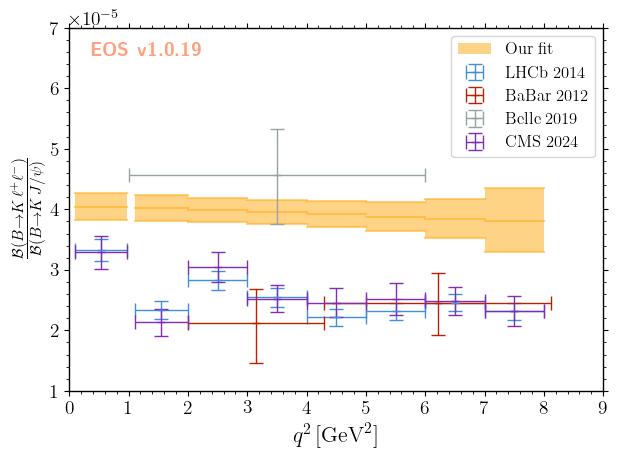

In [6]:
x_range = [0.0, 9.0]

pred_import = eos.data.Prediction(
    os.path.join(BASE_DIRECTORY, 'data', POSTERIOR_NAME, 'pred-BToKll-Normalized-BR-binned')
)
obs_name = 'B->Kll::Normalized_BR'
yrange = [0.00001, 0.00007]

colors = eos.figure.ItemColorCycler()._colors

plot_args = {
    'plot': {
        'x': { 'label': r'$q^2$', 'unit': r'$\textnormal{GeV}^2$', 'range': x_range },
        'y': {
            'label': R'$\frac{\mathcal{B}(B \to K\, \ell^+\ell^-)}{\mathcal{B}(B \to K\, J/\psi)}$',
            'range': yrange
        },
        'legend': { 'location': 'upper right' }
    },
    'contents': [
        {
            'type': 'watermark',
            'position': ['left', 'top']
        },
        {
            'label': r'Our fit',
            'type': 'uncertainty-binned',
            'observable': obs_name,
            'variable': 'q2',
            'range': x_range,
            'rescale-by-width': True,
            'color': colors[1],
            'data-file': f'{BASE_DIRECTORY}/data/{POSTERIOR_NAME}/pred-BToKll-Normalized-BR-binned'
        },
		{
            'label': r'LHCb 2014',
            'type': 'constraint',
            'color': colors[0],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[0.10,0.98]@LHCb:2014A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': None,
            'type': 'constraint',
            'color': colors[0],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[1.10,2.00]@LHCb:2014A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': None,
            'type': 'constraint',
            'color': colors[0],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[2.00,3.00]@LHCb:2014A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': None,
            'type': 'constraint',
            'color': colors[0],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[3.00,4.00]@LHCb:2014A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': None,
            'type': 'constraint',
            'color': colors[0],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[4.00,5.00]@LHCb:2014A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': None,
            'type': 'constraint',
            'color': colors[0],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[5.00,6.00]@LHCb:2014A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': None,
            'type': 'constraint',
            'color': colors[0],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[6.00,7.00]@LHCb:2014A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': None,
            'type': 'constraint',
            'color': colors[0],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[7.00,8.00]@LHCb:2014A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': r'BaBar 2012',
            'type': 'constraint',
            'color': colors[2],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[2.00,4.30]@BaBar:2012A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': None,
            'type': 'constraint',
            'color': colors[2],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[4.30,8.12]@BaBar:2012A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': r'Belle 2019',
            'type': 'constraint',
            'color': colors[3],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR[1.00,6.00]@Belle:2019C',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
        {
            'label': r'CMS 2024',
            'type': 'constraint',
            'color': colors[4],
            'constraints': 'B^+->K^+mu^+mu^-::NormalizedBR_binned@CMS:2024A',
            'observable': 'B->Kll::NormalizedBR',
            'variable': 'q2',
            'rescale-by-width': True
        },
    ]
}

eos.plot.Plotter(plot_args).plot()
ax = plt.gca()
ax.legend(loc='upper right', fontsize=12)

In [ ]:
q2_vals = np.linspace(0,9,900)

pred_import = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', POSTERIOR_NAME, 'pred-BToKll-Normalized-BR'))
obs_name = 'B->Kll::Normalized_dBR/ds'
yrange = range_from_pred(pred_import, obs_name, q2_vals, nsigma=1.5, pad_frac=0.1)

to_plot = [
    (obs_name, R'\frac{1}{\mathcal{B}(B \to K\, J/\psi)}\frac{d\mathcal{B}(B \to K\, \ell^+\ell^-)}{ds}', [0,0.0002], 'BToKll-Normalized-BR'),
]

for qn, latex, yrange, pred in to_plot:
	plot_args = {
		'plot': {
			'x': { 'label': r'$q^2$',      'unit': r'$\textnormal{GeV}^2$', 'range': [0.0, 10.0] },
			'y': { 'label': fr'${latex}$',                                  'range': [0.00002, 0.00005]         },
			'legend': { 'location': 'upper left' }
		},
		'contents': [
			{
          		'label': r'Our fit','type': 'uncertainty', 'range': [0, 10],
				'color': 'C0',
          		'data-file': f'{BASE_DIRECTORY}/data/{POSTERIOR_NAME}/pred-{pred}',
			}
		]
	}
	eos.plot.Plotter(plot_args).plot()
#, f'./plots/{POSTERIOR_NAME}-{pred}.pdf'

In [ ]:
eos.tasks.predict_observables(ANALYSIS_FILE, POSTERIOR_NAME, 'BToK-strong-bound', BASE_DIRECTORY)

In [ ]:
pred = eos.data.Prediction(
    os.path.join(BASE_DIRECTORY, 'data', POSTERIOR_NAME, 'pred-BToK-strong-bound')
)

samples = pred.samples[:, 0]
weights = pred.weights / np.sum(pred.weights)

mean = np.average(samples, weights=weights)

plt.figure(figsize=(7,5))
plt.hist(samples, bins=7500, weights=weights, density=True, alpha=0.6, color='C0', label='posterior')
plt.axvline(1.0, color='crimson', linestyle='--', linewidth=1.5, label='bound = 1')
plt.axvline(mean, color='black', linestyle='-', linewidth=1.5, label=f'mean = {mean:.2f}')

plt.xlim(-1, 4)
plt.xlabel(r'$\mathrm{strong\ bound}$')
plt.ylabel('posterior density')
plt.legend()
plt.tight_layout()
plt.show()
